# OASIS INFOBYTE - TASK 4

## Predicting House Prices with Linear Regression

### Objective
Build and evaluate a Linear Regression model to predict house prices based on features such as area, location, number of rooms, and age.

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("housing.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (545, 13)

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
print("Price Statistics:")
print(df["price"].describe())

Price Statistics:
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64


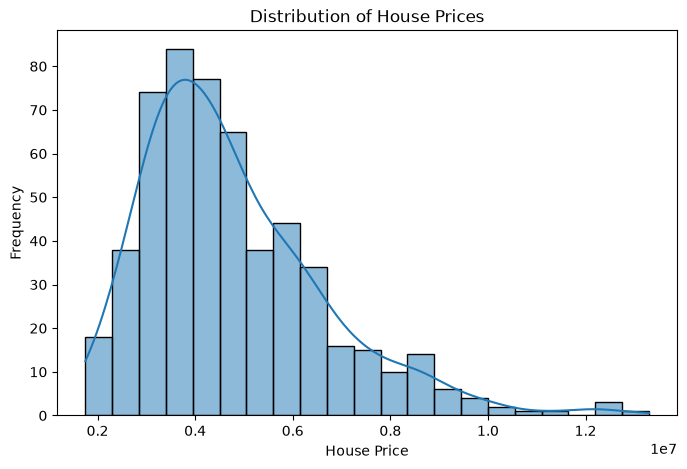

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

In [10]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print(correlation["price"].sort_values(ascending=False))

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


In [11]:
correlation["price"].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

## Feature Selection Discussion

For predicting house prices, we selected features that are likely to have an impact on the price of a house.

The numerical features such as area, bedrooms, bathrooms, stories, and parking are important predictors because larger houses and houses with more facilities generally have higher prices.

The categorical features such as mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, and furnishingstatus may also influence house prices. These features describe the location, facilities, and condition of the house.

From the correlation analysis, area has the highest positive correlation with price among the numerical features, followed by bathrooms, stories, parking, and bedrooms.

Therefore, these features will be considered when building the Linear Regression model.

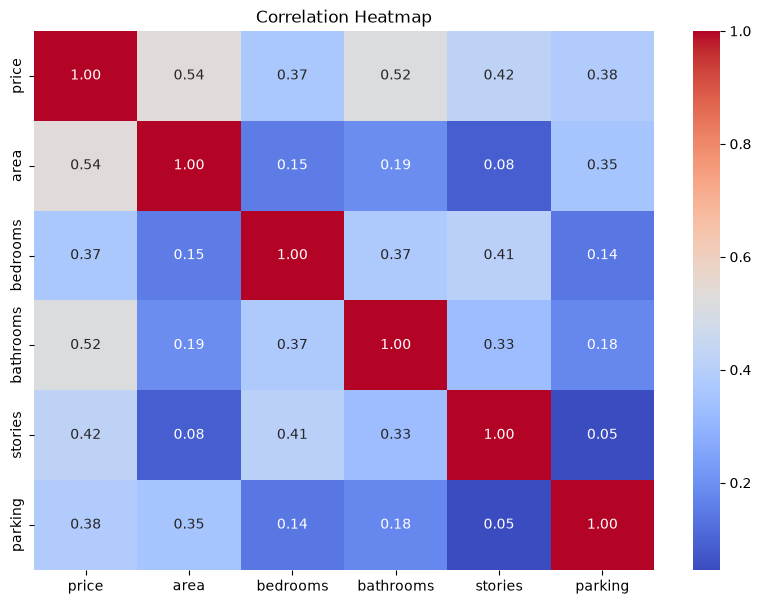

In [12]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
X = df.drop("price", axis=1)
y = df["price"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

Features (X):
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Target (y):
price


In [15]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["str"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing setup completed successfully!")

Preprocessing setup completed successfully!


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 12)
Testing data: (109, 12)


In [18]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


In [19]:
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 predicted prices:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predicted prices:
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556559 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
Mean Squared Error (MSE): 1754318687330.6614
Root Mean Squared Error (RMSE): 1324506.9600914377
R² Score: 0.6529242642153188


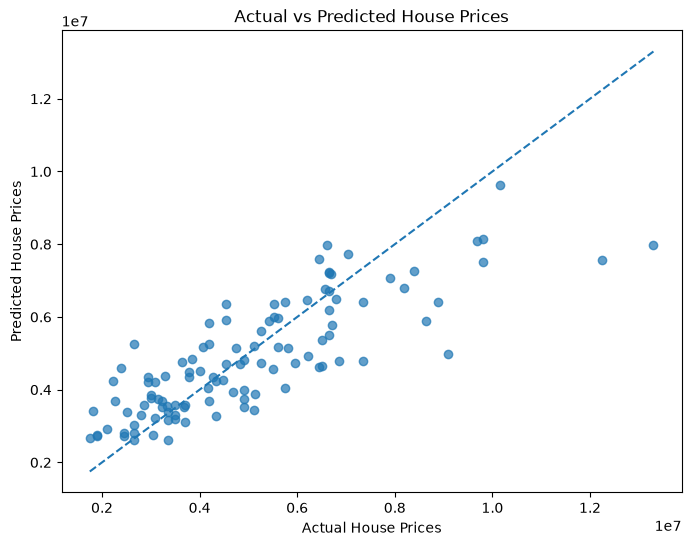

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Diagonal reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

Actual Price − Predicted Price

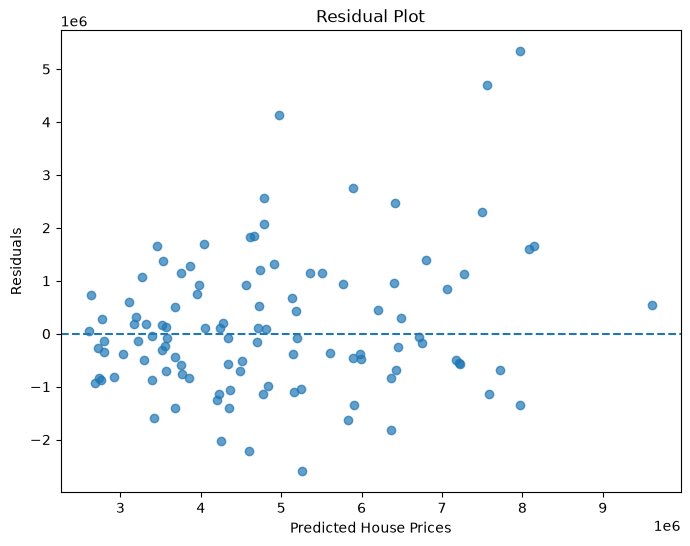

In [24]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [25]:
# Get feature names after preprocessing
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

# Get model coefficients
coefficients = linear_model.named_steps["regressor"].coef_

# Create a DataFrame
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df

,Feature,Coefficient
2,num__bathrooms,1.094445e+06
3,num__stories,4.074766e+05
14,cat__airconditioning_yes,3.957134e+05
12,cat__hotwaterheating_yes,3.423249e+05
16,cat__prefarea_yes,3.149453e+05
4,num__parking,2.248419e+05
10,cat__basement_yes,1.951256e+05
6,cat__mainroad_yes,1.839600e+05
17,cat__furnishingstatus_furnished,1.801756e+05
8,cat__guestroom_yes,1.158050e+05


In [26]:
print("Top 5 Positive Features:")
print(coefficient_df.head(5))

print("\nTop 5 Negative Features:")
print(coefficient_df.tail(5))

Top 5 Positive Features:
                     Feature   Coefficient
2             num__bathrooms  1.094445e+06
3               num__stories  4.074766e+05
14  cat__airconditioning_yes  3.957134e+05
12  cat__hotwaterheating_yes  3.423249e+05
16         cat__prefarea_yes  3.149453e+05

Top 5 Negative Features:
                              Feature    Coefficient
9                    cat__basement_no -195125.588091
19  cat__furnishingstatus_unfurnished -233469.435624
15                   cat__prefarea_no -314945.282657
11            cat__hotwaterheating_no -342324.942669
13            cat__airconditioning_no -395713.367922


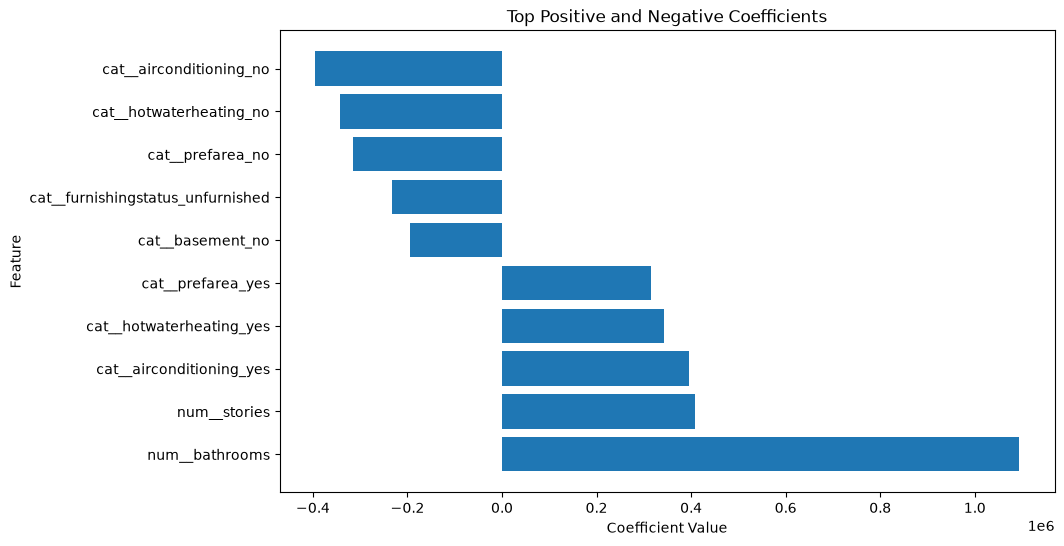

In [27]:
top_coefficients = pd.concat([
    coefficient_df.head(5),
    coefficient_df.tail(5)
])

plt.figure(figsize=(10, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Positive and Negative Coefficients")

plt.show()

In [28]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

print("Ridge Regression model created successfully!")

Ridge Regression model created successfully!


In [29]:
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")

Ridge Regression model trained successfully!


In [30]:
ridge_pred = ridge_model.predict(X_test)

print("Ridge predictions generated successfully!")
print(ridge_pred[:10])

Ridge predictions generated successfully!
[5165800.6292089  7210284.35227031 3111086.15379219 4613477.69618395
 3298282.08024    3539094.58971591 5616359.24782334 6359142.22901145
 2727550.52868246 2634836.05520993]


In [31]:
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("------------------------")
print("Mean Squared Error (MSE):", ridge_mse)
print("Root Mean Squared Error (RMSE):", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression Results
------------------------
Mean Squared Error (MSE): 1754669869766.609
Root Mean Squared Error (RMSE): 1324639.524461885
R² Score: 0.6528547860166134


In [32]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,1.754319e+12,1.324507e+06,0.652924
1,Ridge Regression,1.754670e+12,1.324640e+06,0.652855


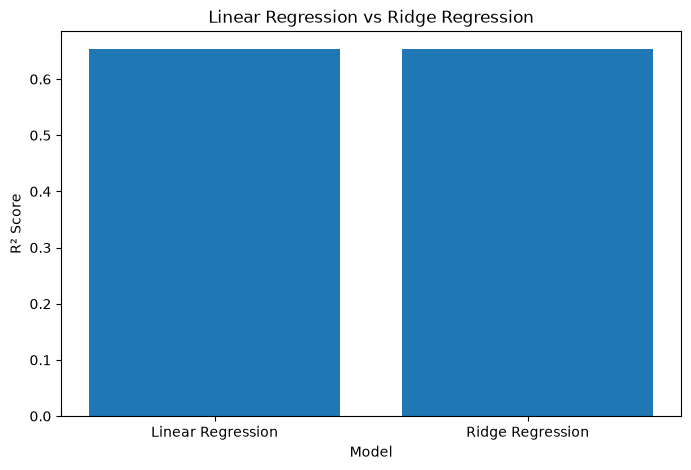

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Linear Regression vs Ridge Regression")

plt.show()

## Conclusion

In this project, a Linear Regression model was developed to predict house prices using features such as area, bedrooms, bathrooms, stories, parking, location-related features, and house facilities.

The dataset was first explored using descriptive statistics, missing-value analysis, price distribution, and correlation analysis. The dataset contained no missing values.

Categorical features were converted into numerical form using One-Hot Encoding. The data was then divided into 80% training data and 20% testing data.

The Linear Regression model achieved an R² score of approximately 0.653, meaning that the model explained about 65.3% of the variation in house prices on the test dataset.

Actual versus predicted price and residual plots were used to visually evaluate the model. Coefficient analysis was also performed to understand the positive and negative influence of different features on predicted house prices.

As a bonus, Ridge Regression was implemented and compared with Linear Regression using MSE, RMSE, and R² score. The model with lower error and higher R² score can be considered the better-performing model for this dataset.